<a href="https://colab.research.google.com/github/KelseyyB/Deep-Learning/blob/main/pytorch1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

In [36]:
transform = transforms.Compose([
    transforms.ToTensor()
])
train_full = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform)
print(len(train_full))
print(len(test_dataset))

50000
10000


In [37]:
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(
    train_full,
    [train_size, val_size])

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 40000
Validation: 10000
Test: 10000


In [38]:

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False)

In [39]:
class FFNClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(3072, 1024),
            nn.ReLU(),

            nn.Linear(1024, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 10)

        )

    def forward(self, x):
        return self.network(x)

In [40]:
model = FFNClassifier().to(device)

print(model)

FFNClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=1024, bias=True)
    (2): ReLU()
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): ReLU()
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [41]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001)

In [42]:
def calculate_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    return 100 * correct / total

In [44]:
epochs = 20

train_acc_list = []
val_acc_list = []
test_acc_list = []

for epoch in range(epochs):

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

    train_acc = calculate_accuracy(
        model,
        train_loader
    )

    val_acc = calculate_accuracy(
        model,
        val_loader
    )

    test_acc = calculate_accuracy(
        model,
        test_loader
    )

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    test_acc_list.append(test_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train: {train_acc:.2f}% | "
        f"Val: {val_acc:.2f}% | "
        f"Test: {test_acc:.2f}%"
    )

Epoch 1/20 | Train: 63.66% | Val: 51.42% | Test: 51.61%
Epoch 2/20 | Train: 64.51% | Val: 50.89% | Test: 51.51%
Epoch 3/20 | Train: 66.94% | Val: 51.97% | Test: 52.06%
Epoch 4/20 | Train: 67.08% | Val: 51.00% | Test: 51.41%
Epoch 5/20 | Train: 66.46% | Val: 50.83% | Test: 51.21%
Epoch 6/20 | Train: 68.45% | Val: 51.42% | Test: 51.46%
Epoch 7/20 | Train: 68.81% | Val: 51.09% | Test: 51.36%
Epoch 8/20 | Train: 70.76% | Val: 51.56% | Test: 51.23%
Epoch 9/20 | Train: 71.89% | Val: 52.20% | Test: 51.46%
Epoch 10/20 | Train: 71.71% | Val: 50.84% | Test: 51.32%
Epoch 11/20 | Train: 72.94% | Val: 50.72% | Test: 50.61%
Epoch 12/20 | Train: 73.48% | Val: 51.12% | Test: 51.32%
Epoch 13/20 | Train: 71.71% | Val: 49.72% | Test: 49.62%
Epoch 14/20 | Train: 74.73% | Val: 50.66% | Test: 51.17%
Epoch 15/20 | Train: 74.53% | Val: 48.97% | Test: 49.39%
Epoch 16/20 | Train: 76.59% | Val: 50.70% | Test: 50.73%
Epoch 17/20 | Train: 78.14% | Val: 50.54% | Test: 50.89%
Epoch 18/20 | Train: 78.65% | Val: 50.48

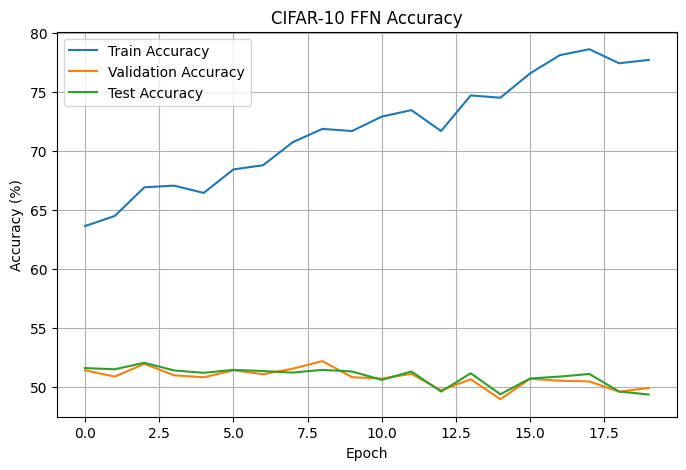

In [47]:
plt.figure(figsize=(8,5))

plt.plot(
    train_acc_list,
    label="Train Accuracy"
)

plt.plot(
    val_acc_list,
    label="Validation Accuracy"
)

plt.plot(
    test_acc_list,
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "CIFAR-10 FFN Accuracy"
)

plt.legend()

plt.grid()

plt.show()

In [48]:
classes = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck']
image, label = test_dataset[0]

In [49]:
model.eval()

with torch.no_grad():

    output = model(
        image.unsqueeze(0).to(device)
    )

    _, prediction = torch.max(
        output,
        1
    )

predicted_class = classes[
    prediction.item()
]

actual_class = classes[label]

print("Actual:", actual_class)
print("Predicted:", predicted_class)

Actual: cat
Predicted: cat


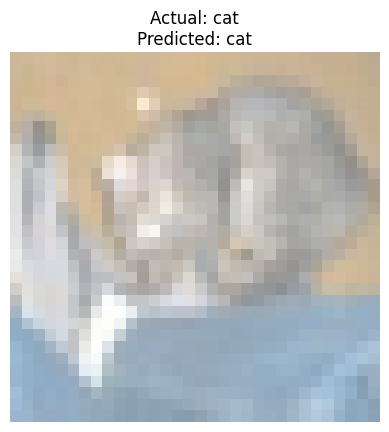

In [50]:
img = image / 2 + 0.5

plt.imshow(
    img.permute(1,2,0)
)

plt.title(
    f"Actual: {actual_class}\nPredicted: {predicted_class}"
)

plt.axis("off")

plt.show()